# Figure 1a: Split Sensitivity

This notebook plots the percentage of land grid cells with positive changes in Niño 3.4 correlations at $\Delta r > 0.4$, $0.6$, and $0.8$. The x-axis is the P2 period start year (1991–2016).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 16,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.dpi': 150,
})

DATA_FILENAME = 'dcorr_nino34_djf_split_metrics_1981_2025.xlsx'
FIGURE_DIR = Path('/Users/rizzie/Work/PaperENSO/Scripts_v2/Fig1/Identification_threshold_positive')
data_candidates = (
    FIGURE_DIR / DATA_FILENAME,
    Path.cwd() / DATA_FILENAME,
)
DATA_PATH = next((path for path in data_candidates if path.exists()), None)
if DATA_PATH is None:
    searched = '\n'.join(str(path) for path in data_candidates)
    raise FileNotFoundError(f'Metrics workbook not found. Searched:\n{searched}')

OUTPUT_PATH = DATA_PATH.with_name('Fig1a.png')


In [2]:
metrics = pd.read_excel(DATA_PATH).sort_values('p2_start').reset_index(drop=True)

required_columns = {
    'p2_start',
    'percent_land_positive_change_gt_040',
    'percent_land_positive_change_gt_060',
    'percent_land_positive_change_gt_080',
}
missing_columns = required_columns.difference(metrics.columns)
if missing_columns:
    raise ValueError(f'Metrics workbook is missing columns: {sorted(missing_columns)}')

print(f'Loaded {len(metrics)} split periods from {DATA_PATH.name}.')


Loaded 26 split periods from dcorr_nino34_djf_split_metrics_1981_2025.xlsx.


Figure saved to: /Users/rizzie/Work/PaperENSO/Scripts_v2/Fig1/Identification_threshold_positive/Fig1a.png


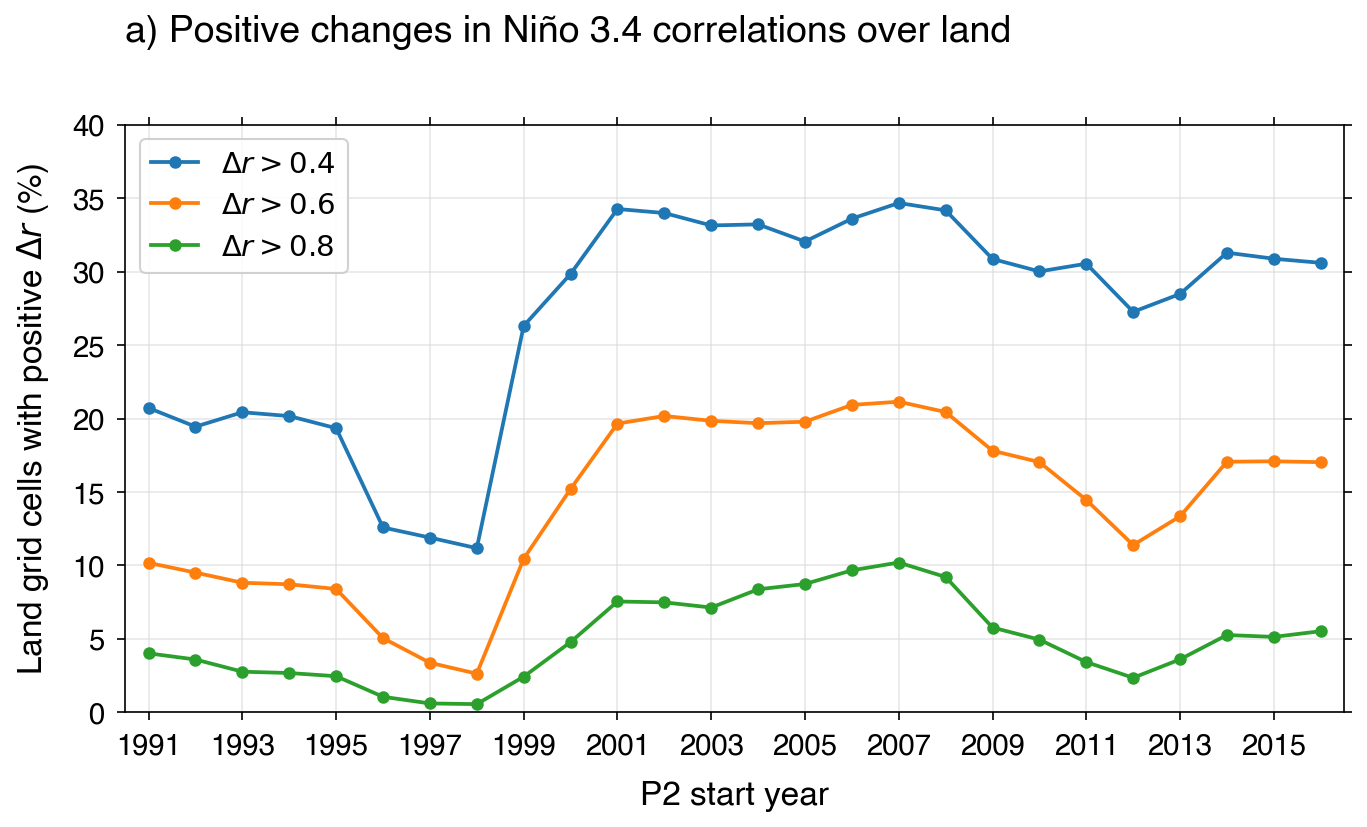

In [3]:
threshold_columns = {
    0.4: 'percent_land_positive_change_gt_040',
    0.6: 'percent_land_positive_change_gt_060',
    0.8: 'percent_land_positive_change_gt_080',
}

fig, ax = plt.subplots(figsize=(9, 5.4), constrained_layout=True)
for threshold, column in threshold_columns.items():
    ax.plot(
        metrics['p2_start'],
        metrics[column],
        marker='o',
        markersize=5,
        linewidth=1.8,
        label=fr'$\Delta r > {threshold}$',
    )

ax.set_title('a) Positive changes in Niño 3.4 correlations over land', loc='left', pad=40)
ax.set_xlabel('P2 start year', labelpad=10)
ax.set_ylabel('Land grid cells with positive $\Delta r$ (%)', labelpad=10)
ax.set_xlim(metrics['p2_start'].min() - 0.5, metrics['p2_start'].max() + 0.5)
ax.set_xticks(np.arange(metrics['p2_start'].min(), metrics['p2_start'].max() + 1, 2))
ax.set_ylim(0, 40)
ax.set_yticks(np.arange(0, 41, 5))
ax.grid(True, color='0.85', linewidth=0.8, alpha=0.6)
ax.tick_params(axis='both', which='major', direction='out', length=4, width=0.8, top=True, right=True, pad=6)
ax.legend(loc='upper left', frameon=True, framealpha=0.9, borderpad=0.4, handlelength=1.6)

fig.savefig(OUTPUT_PATH, dpi=300, bbox_inches='tight')
print(f'Figure saved to: {OUTPUT_PATH}')
plt.show()
